# Single-Asset Model Comparison (BTC/USDT)

Compare baselines, econometric, ML, statistical, dummy, and ensemble strategies on the same **test period**.
Business logic lives in `src/crypto_hf/` — this notebook only loads config, runs the pipeline, and visualizes reports.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

from crypto_hf.config import load_single_asset_models_config
from crypto_hf.data.loader import load_ohlcv_csv
from crypto_hf.pipeline.single_asset_models import (
    prepare_model_dataset,
    run_single_asset_models_pipeline,
)
from crypto_hf.pipeline.threshold_calibration import split_train_validation_test

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Config and strategy groups

In [2]:
config = load_single_asset_models_config(PROJECT_ROOT / "configs" / "single_asset_models.yaml")
config

SingleAssetModelsConfig(symbol='BTC/USDT', timeframe='1d', data_path=PosixPath('/home/gwyllan/projects/ai-crypto-hedge-fund/data/raw/BTC_USDT_1d.csv'), initial_cash=10000.0, fee_rate=0.001, slippage=0.0, train_size=0.7, fast_window=10, slow_window=30, volatility_window=20, annualization_factor=365, return_lags=[1, 2, 3, 5], rolling_mean_windows=[5, 10, 20], rolling_vol_windows=[10, 20], momentum_windows=[5, 10, 20], sma_ratio_windows=[10, 20], rsi_window=14, econometric_lags=5, econometric_use_cost_threshold=True, ml_probability_threshold=0.5, logistic_regression_c=1.0, logistic_regression_max_iter=1000, enable_random_forest=True, random_forest_n_estimators=100, enable_gradient_boosting=True, gradient_boosting_n_estimators=100, enable_ridge_regression=True, ridge_alpha=1.0, enable_dummy_baselines=True, validation_size_within_train=0.2, ml_threshold_candidates=[0.45, 0.5, 0.55, 0.6], zscore_window=20, zscore_entry_threshold=-1.0, zscore_exit_threshold=1.0, breakout_window=20, stat_momen

In [3]:
pd.Series(
    {
        "Benchmarks": ["buy_and_hold", "sma_crossover"],
        "Econometric": ["econometric_autoreg"],
        "ML": [
            "ml_logistic_regression",
            "ml_random_forest",
            "ml_gradient_boosting",
            "ml_ridge_regression",
        ],
        "Statistical": [
            "stat_zscore_mean_reversion",
            "stat_momentum_breakout",
            "stat_volatility_regime_filter",
        ],
        "Dummy / ensemble": [
            "dummy_always_long",
            "dummy_always_cash",
            "dummy_random_signal",
            "ensemble_majority_vote",
        ],
    }
)

Benchmarks                              [buy_and_hold, sma_crossover]
Econometric                                     [econometric_autoreg]
ML                  [ml_logistic_regression, ml_random_forest, ml_...
Statistical         [stat_zscore_mean_reversion, stat_momentum_bre...
Dummy / ensemble    [dummy_always_long, dummy_always_cash, dummy_r...
dtype: object

## 2. Dataset summary

In [4]:
raw = load_ohlcv_csv(config.data_path)
dataset, feature_cols = prepare_model_dataset(raw, config)
train, validation, test = split_train_validation_test(
    dataset,
    config.train_size,
    config.validation_size_within_train,
)
print(f"Features: {len(feature_cols)}")
print(f"Train: {len(train)} | Validation: {len(validation)} | Test: {len(test)}")

Features: 14
Train: 548 | Validation: 137 | Test: 294


## 3. Run pipeline

In [5]:
outputs = run_single_asset_models_pipeline(config, reports_dir=PROJECT_ROOT / "reports")
outputs.trading_metrics

,total_return,cagr,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,number_of_trades,turnover
strategy,,,,,,,,,
buy_and_hold,-0.422007,-0.494851,0.451260,-1.280058,-1.726541,-0.511589,-0.967283,1.0,1.0
sma_crossover,-0.178929,-0.217758,0.236753,-0.914968,-0.867014,-0.240891,-0.903968,6.0,12.0
econometric_autoreg,-0.344360,-0.408964,0.365206,-1.248042,-1.437082,-0.411667,-0.993435,64.0,127.0
ml_logistic_regression,-0.479340,-0.556491,0.436037,-1.636861,-2.133689,-0.529495,-1.050984,21.0,41.0
ml_random_forest,-0.565626,-0.646104,0.401246,-2.373716,-2.744764,-0.592408,-1.090641,44.0,87.0
ml_gradient_boosting,-0.141307,-0.172858,0.342537,-0.379419,-0.400241,-0.286277,-0.603814,60.0,119.0
ml_ridge_regression,-0.333819,-0.397104,0.394226,-1.080162,-1.334925,-0.380713,-1.043053,52.0,103.0
dummy_always_long,-0.422007,-0.494851,0.451260,-1.280058,-1.726541,-0.511589,-0.967283,1.0,1.0
dummy_always_cash,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


## 4. Thresholds and validation sweep

In [6]:
outputs.selected_thresholds

,model,selected_threshold
0,econometric_autoreg,0.001000
1,ml_logistic_regression,0.450000
2,ml_random_forest,0.450000
3,ml_gradient_boosting,0.550000
4,ml_ridge_regression,0.001000
5,stat_volatility_regime_filter,0.518373


In [7]:
outputs.threshold_validation

,model,threshold,validation_total_return,validation_sharpe_ratio,validation_max_drawdown,validation_exposure_time,validation_number_of_trades,selected
0,ml_logistic_regression,0.45,0.239643,2.093459,-0.139072,0.839416,14.0,True
1,ml_logistic_regression,0.50,0.113941,1.276318,-0.183054,0.598540,26.0,False
2,ml_logistic_regression,0.55,0.061085,0.918181,-0.086332,0.299270,20.0,False
3,ml_logistic_regression,0.60,0.064801,1.976816,-0.019416,0.072993,8.0,False
4,ml_random_forest,0.45,0.329864,2.840233,-0.094096,0.642336,27.0,True
5,ml_random_forest,0.50,0.134440,1.587846,-0.081958,0.503650,30.0,False
6,ml_random_forest,0.55,0.106607,1.575440,-0.057254,0.313869,27.0,False
7,ml_random_forest,0.60,0.075339,1.365008,-0.049327,0.153285,18.0,False
8,ml_gradient_boosting,0.45,0.262968,2.404477,-0.095647,0.591241,27.0,False
9,ml_gradient_boosting,0.50,0.244096,2.479805,-0.105954,0.459854,31.0,False


## 5. Classification and signal diagnostics

In [8]:
outputs.classification_metrics

,accuracy,precision,recall,f1,roc_auc,confusion_tn,confusion_fp,confusion_fn,confusion_tp
model,,,,,,,,,
econometric_autoreg,0.452381,0.457364,0.848921,0.594458,0.462938,15.0,140.0,21.0,118.0
ml_logistic_regression,0.486395,0.477941,0.935252,0.632603,0.443073,13.0,142.0,9.0,130.0
ml_random_forest,0.421769,0.428571,0.669065,0.522472,0.417823,31.0,124.0,46.0,93.0
ml_gradient_boosting,0.408163,0.377622,0.388489,0.382979,0.403203,66.0,89.0,85.0,54.0
ml_ridge_regression,0.482993,0.473251,0.827338,0.602094,0.455558,27.0,128.0,24.0,115.0
dummy_always_up,0.472789,0.472789,1.000000,0.642032,0.500000,0.0,155.0,0.0,139.0
dummy_always_cash,0.527211,0.000000,0.000000,0.000000,0.500000,155.0,0.0,139.0,0.0
dummy_random_signal,0.465986,0.441558,0.489209,0.464164,0.467185,69.0,86.0,71.0,68.0


In [9]:
outputs.signal_diagnostics[[
    "positive_signal_rate",
    "exposure_time",
    "number_of_signal_changes",
    "net_total_return",
    "gross_total_return",
    "estimated_cost_impact",
    "selected_threshold",
]]

,positive_signal_rate,exposure_time,number_of_signal_changes,net_total_return,gross_total_return,estimated_cost_impact,selected_threshold
strategy,,,,,,,
buy_and_hold,1.000000,0.996599,1.0,-0.422007,-0.421429,0.000578,NaN
sma_crossover,0.394558,0.394558,12.0,-0.178929,-0.169017,0.009912,NaN
econometric_autoreg,0.724490,0.721088,127.0,-0.344360,-0.255576,0.088784,0.001000
ml_logistic_regression,0.925170,0.921769,41.0,-0.479340,-0.457549,0.021790,0.450000
ml_random_forest,0.738095,0.734694,87.0,-0.565626,-0.526143,0.039483,0.450000
ml_gradient_boosting,0.486395,0.486395,120.0,-0.141307,-0.032794,0.108513,0.550000
ml_ridge_regression,0.721088,0.717687,103.0,-0.333819,-0.261545,0.072275,0.001000
dummy_always_long,1.000000,0.996599,1.0,-0.422007,-0.421429,0.000578,NaN
dummy_always_cash,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN


## 6. Grouped equity and drawdown plots

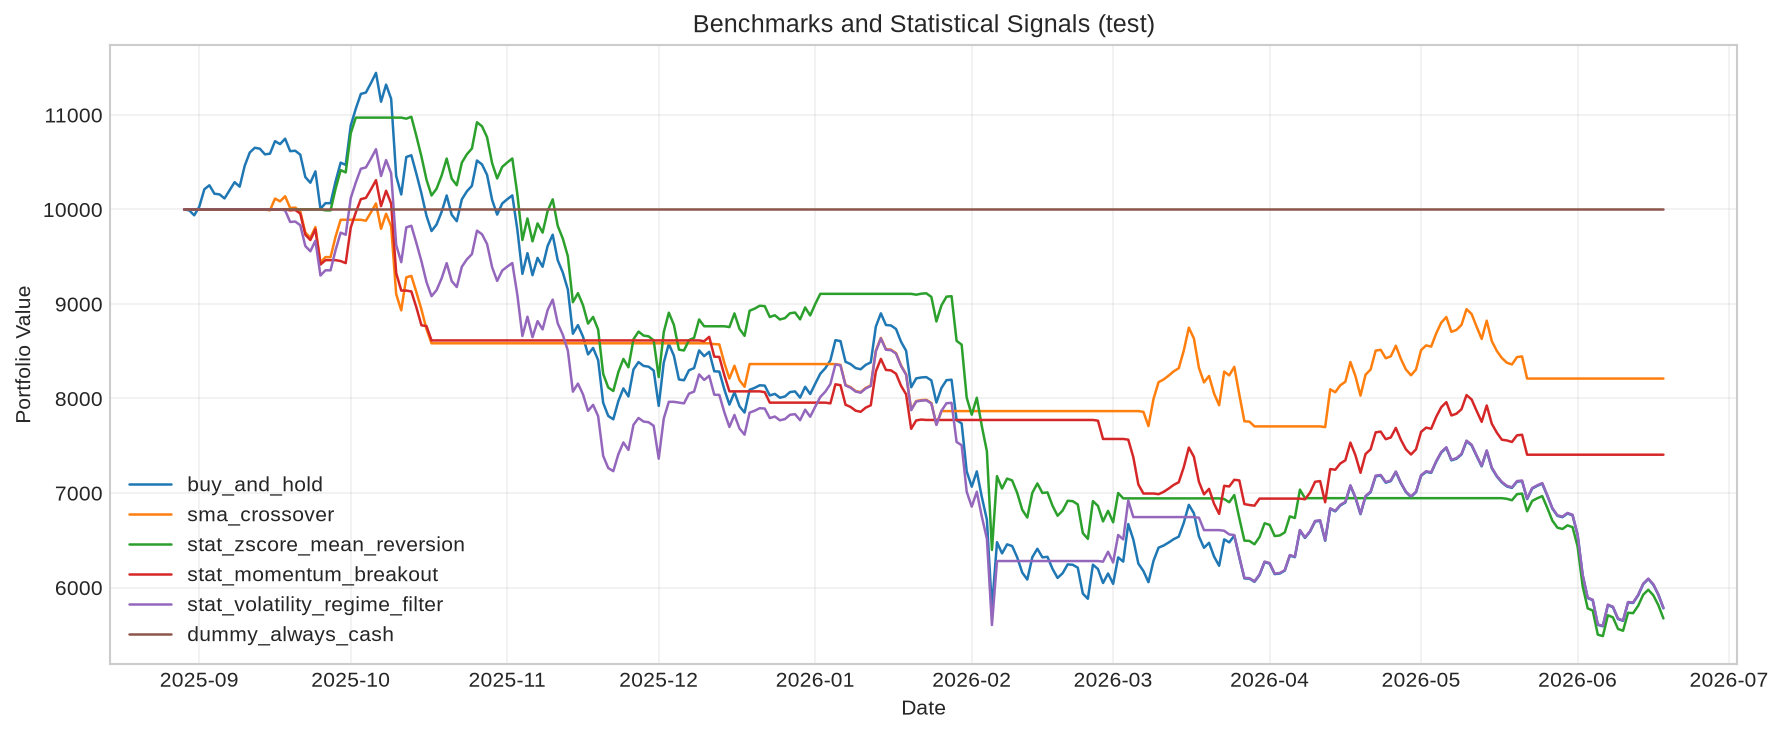

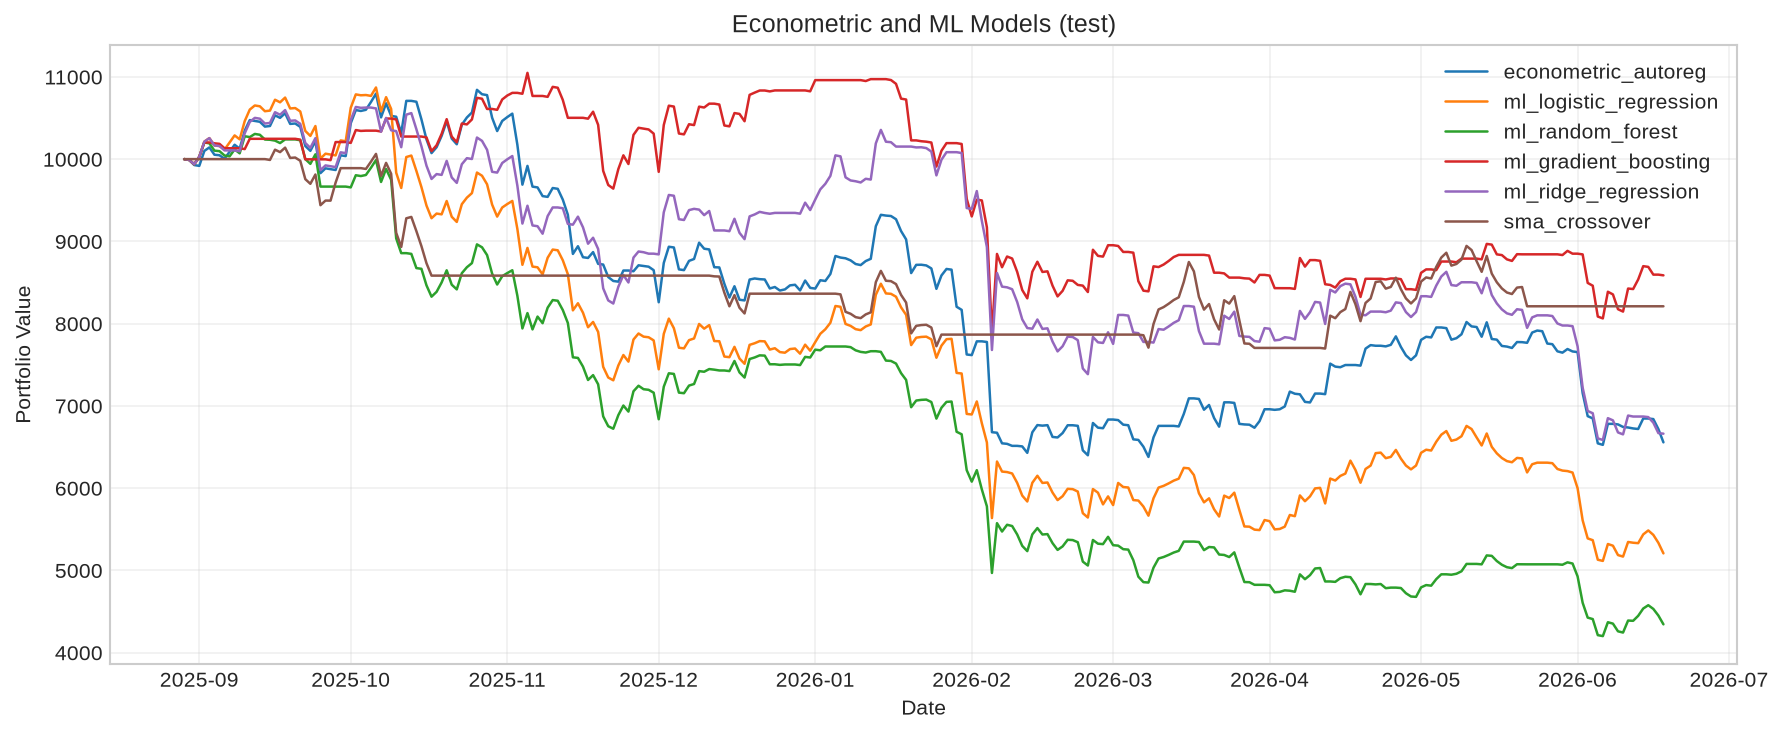

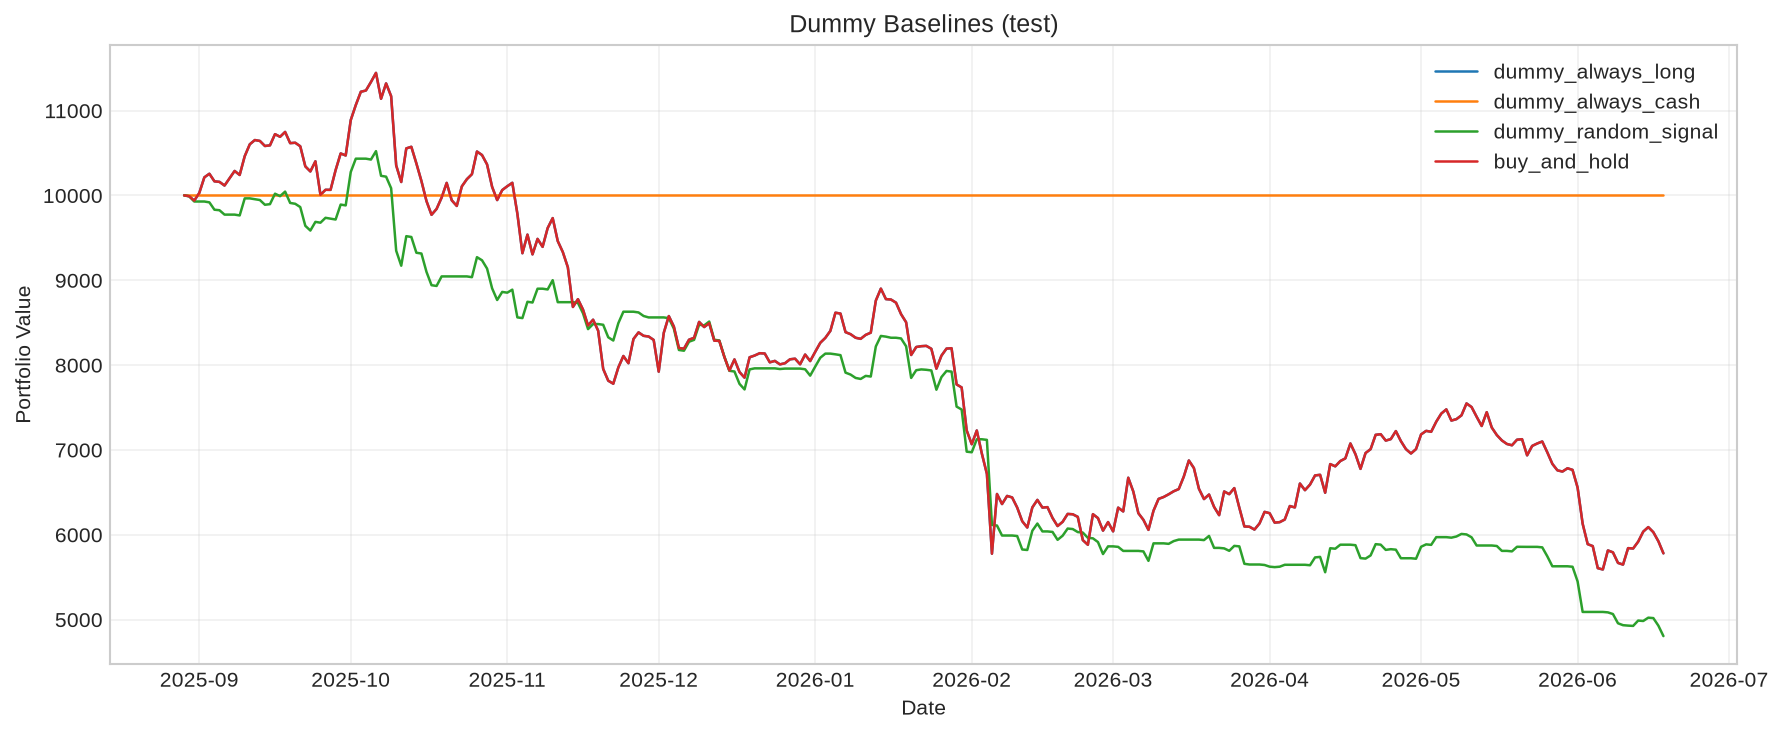

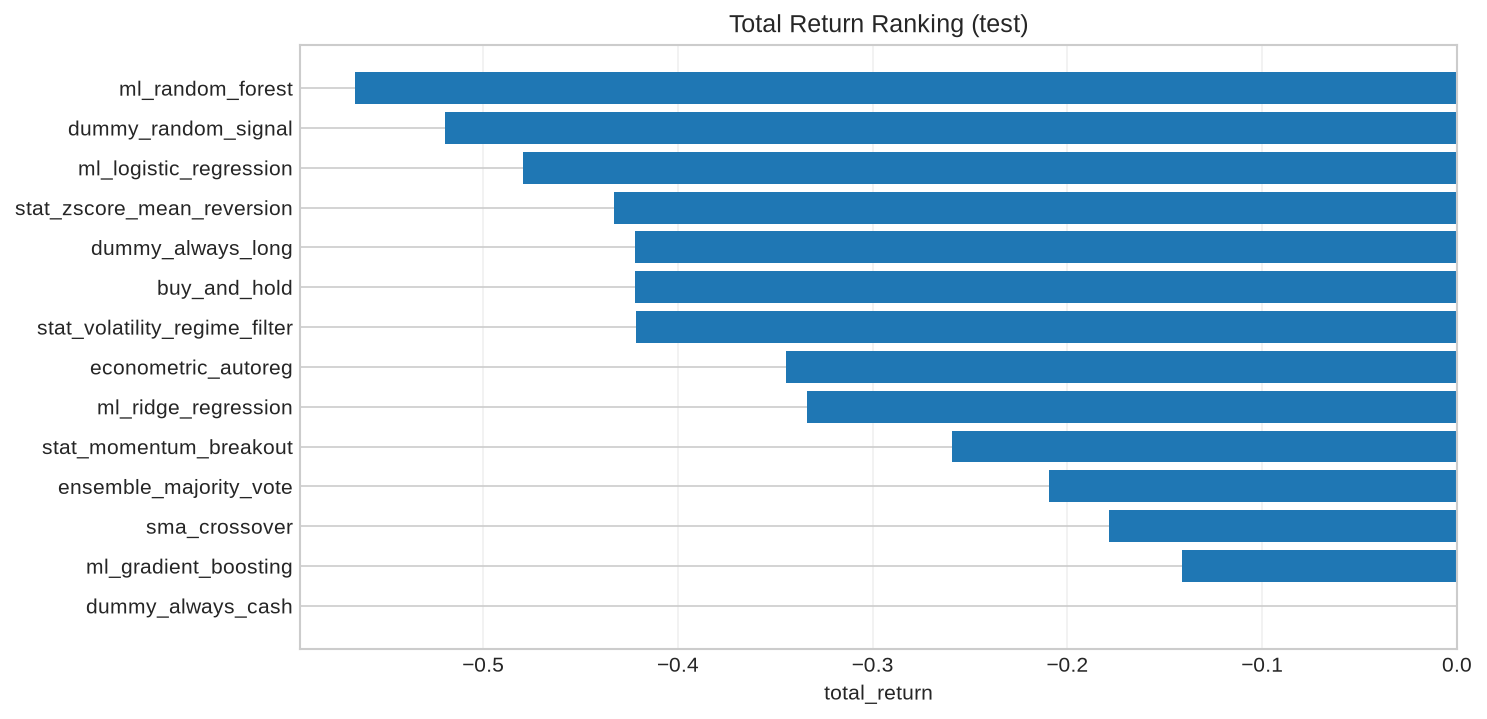

In [10]:
from IPython.display import Image, display

figures_dir = PROJECT_ROOT / "reports" / "figures"
for name in [
    "single_asset_equity_benchmarks_statistical.png",
    "single_asset_equity_models.png",
    "single_asset_equity_dummy_baselines.png",
    "single_asset_total_return_ranking.png",
]:
    path = figures_dir / name
    if path.exists():
        display(Image(filename=path))

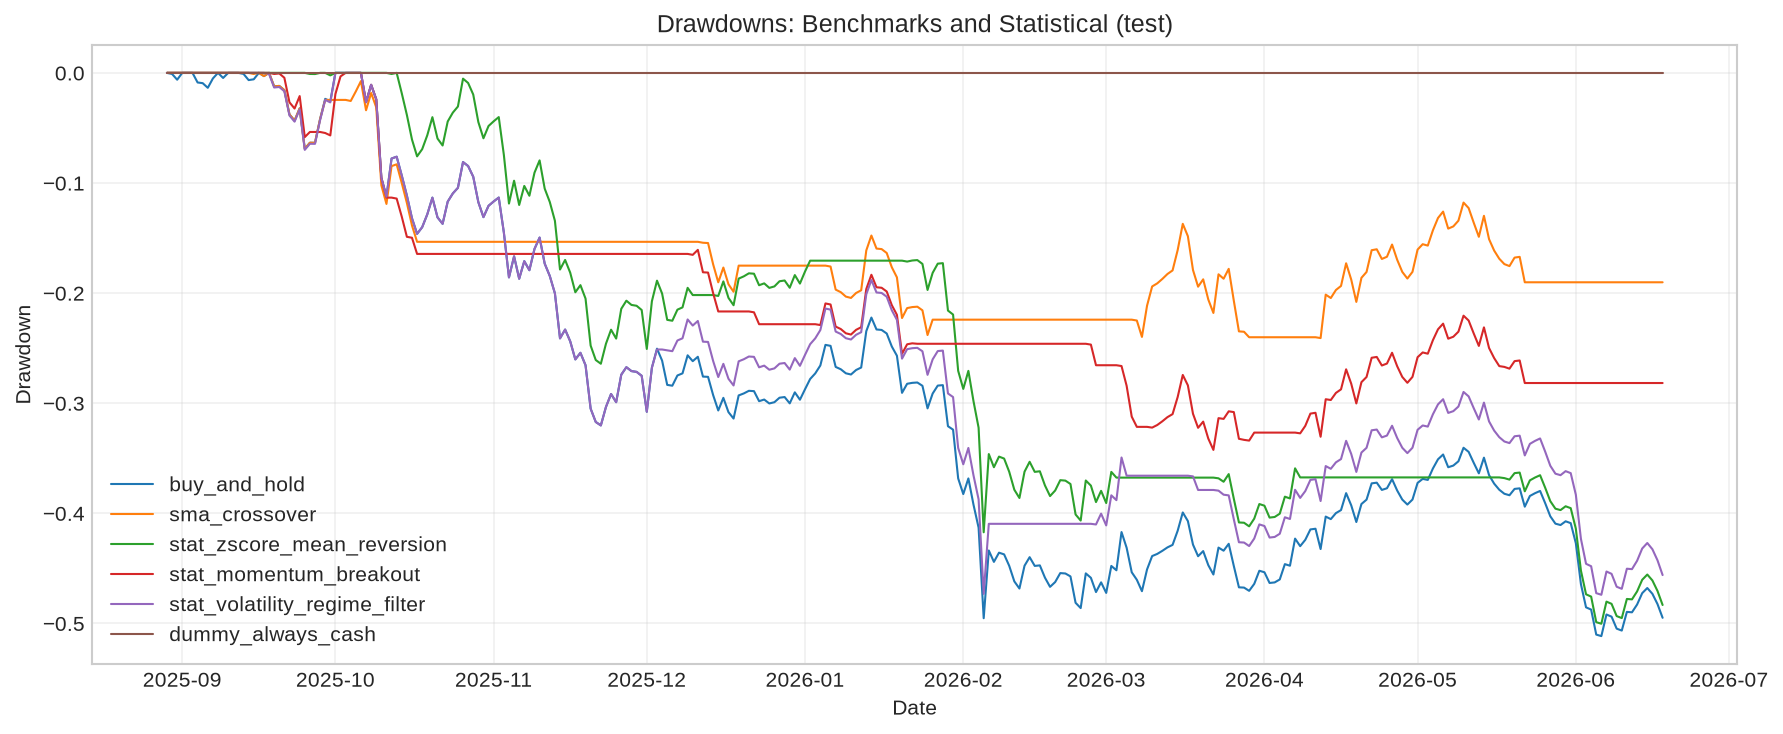

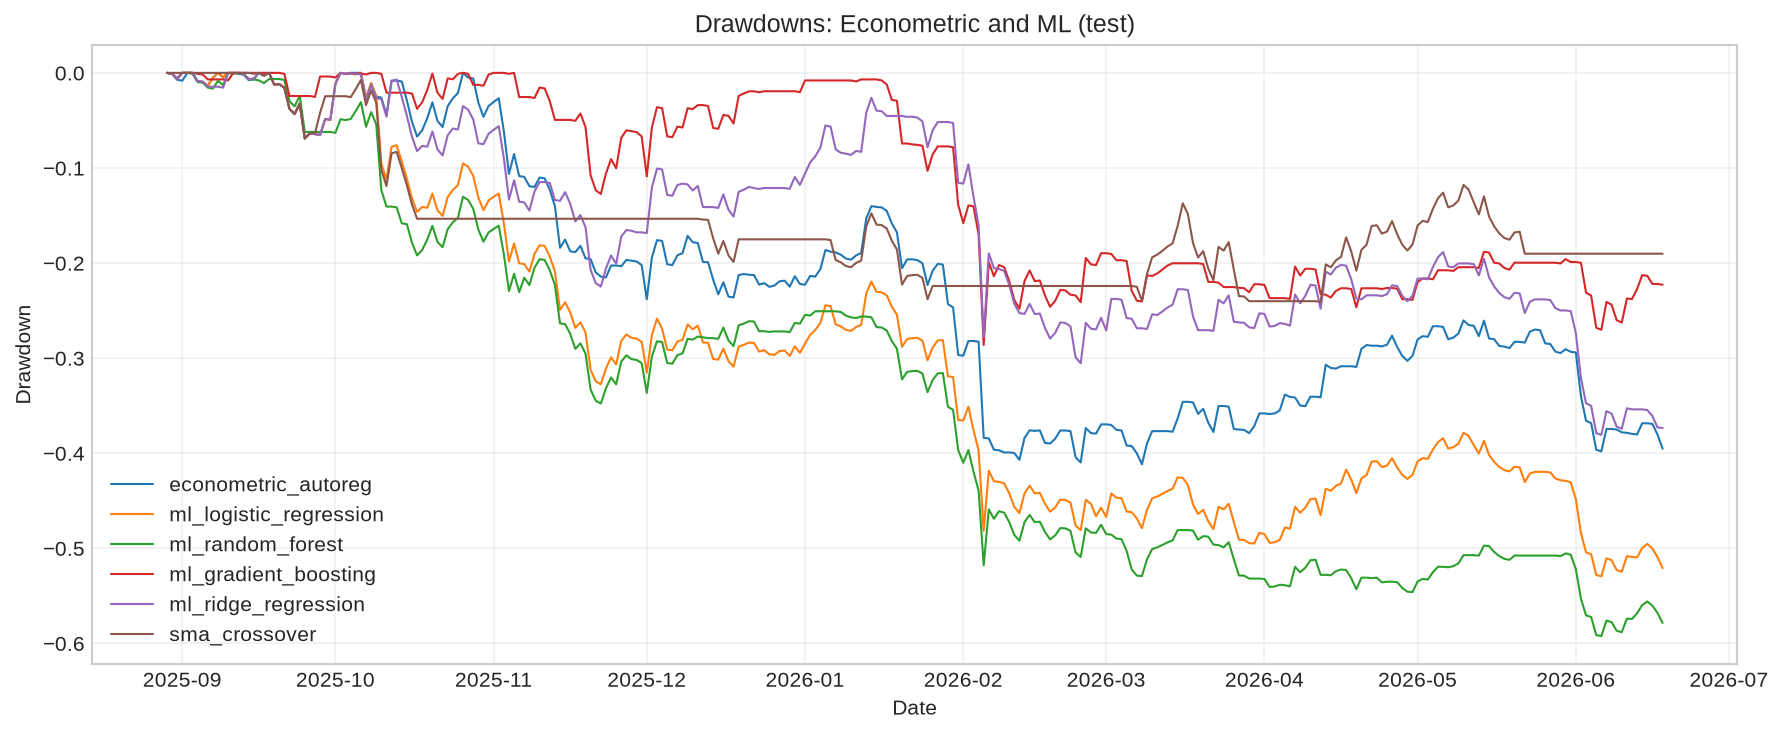

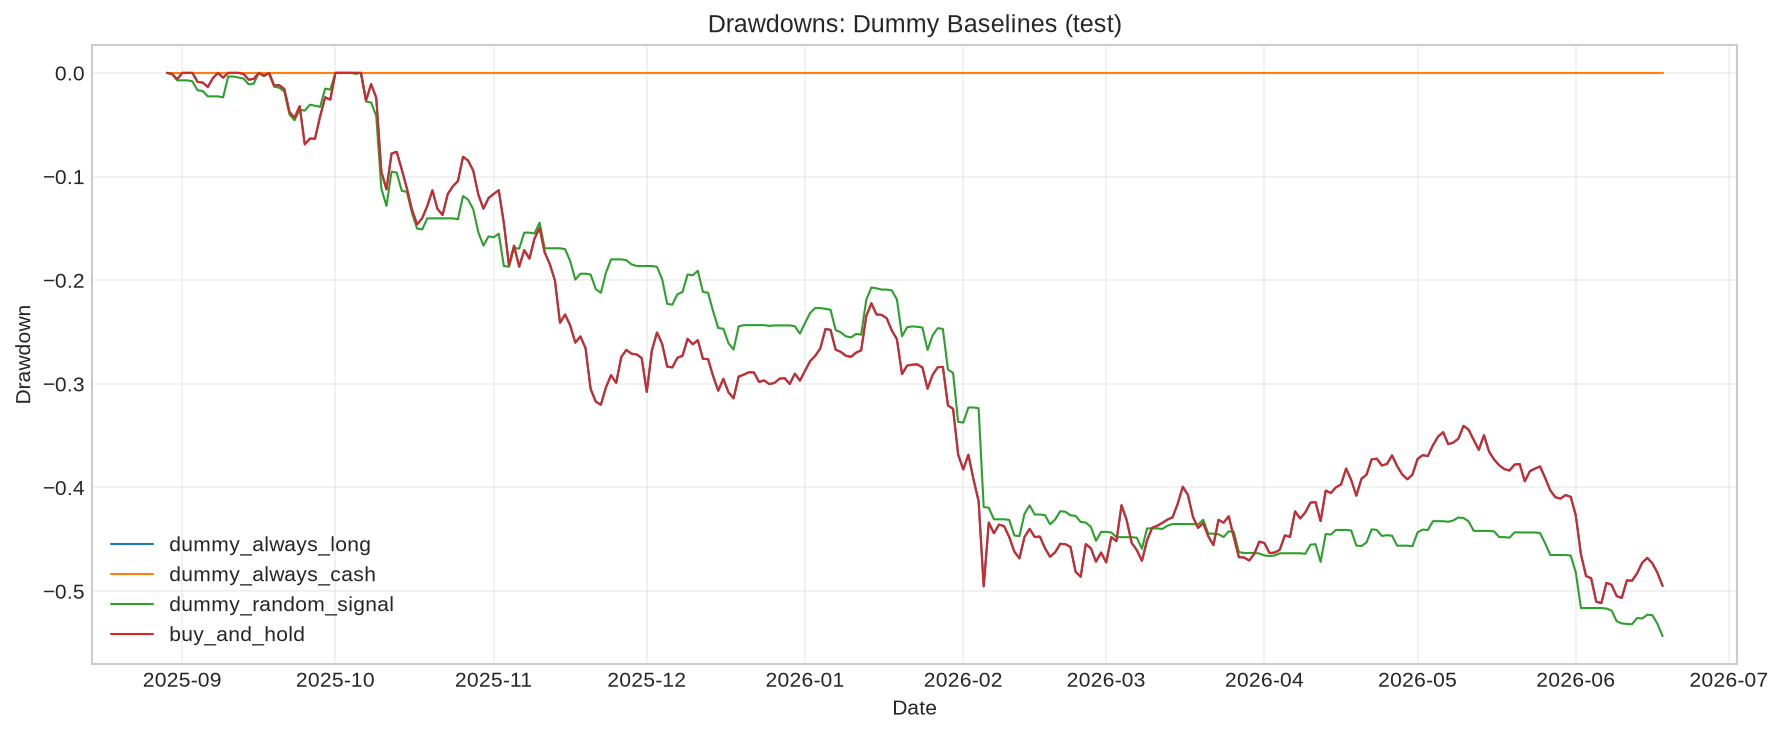

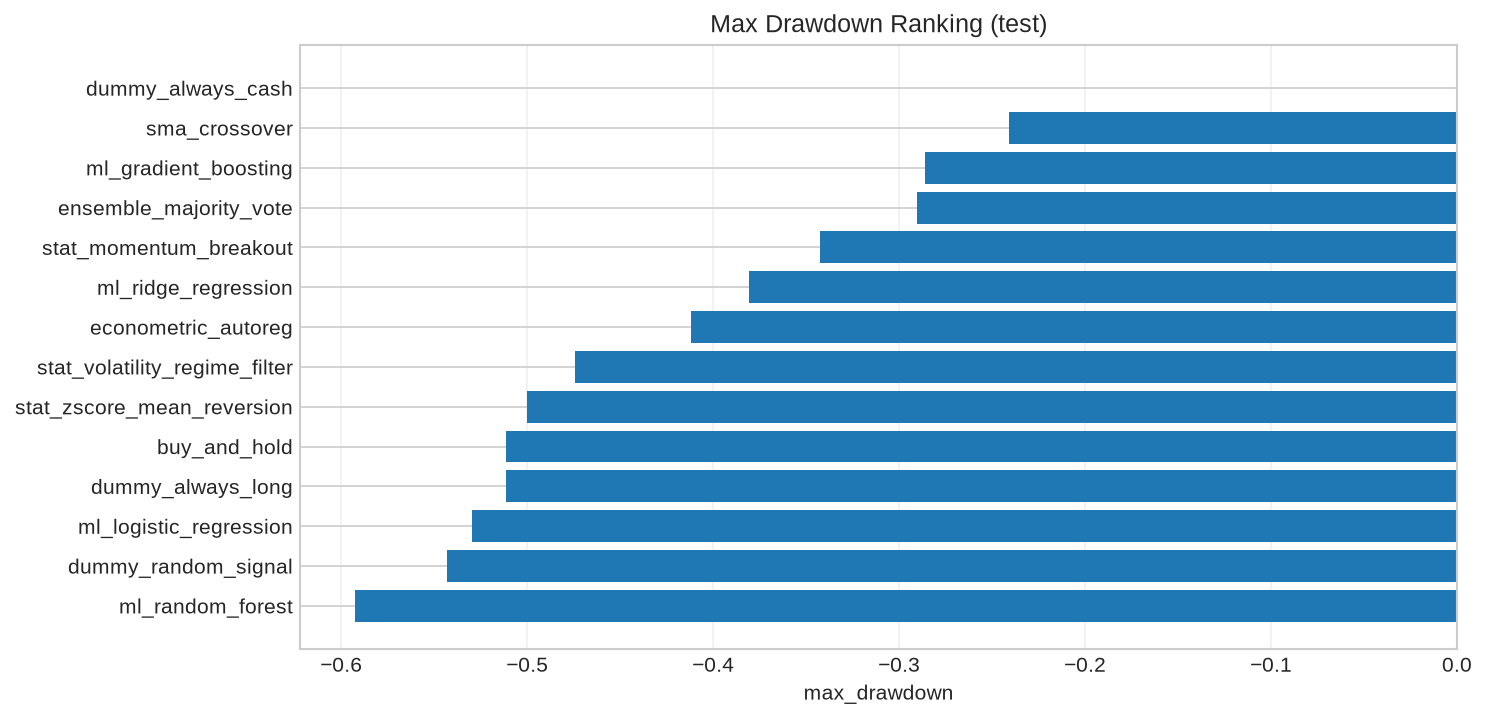

In [11]:
for name in [
    "single_asset_drawdowns_benchmarks_statistical.png",
    "single_asset_drawdowns_models.png",
    "single_asset_drawdowns_dummy_baselines.png",
    "single_asset_max_drawdown_ranking.png",
]:
    path = figures_dir / name
    if path.exists():
        display(Image(filename=path))

## 7. Interpretation

- **SMA crossover** often remains a strong simple baseline on daily BTC.
- ML, econometric, statistical, dummy, and ensemble signals form a **correct signal universe** integrated into one backtester — weak or negative test performance is expected and not a pipeline bug.
- **`dummy_always_cash`** is a sanity check, not a trading idea: it stays in cash (`signal = 0`), so net return ≈ 0 and classification accuracy ≈ the share of down-days. Use it to verify the pipeline and to see whether a model is worse than doing nothing.
- Threshold selection uses the **validation split only**; test metrics are out-of-sample for both models and thresholds.
- Signal diagnostics now separate **net** vs **gross** returns to show fee/slippage impact.
- Ranking plots show the best strategies at the **top** of the bar chart.
- Agents, portfolio optimization, multi-asset, and live trading are **out of scope** for this stage.